<a href="https://colab.research.google.com/github/franknstone92/MPV3/blob/main/WST3_Exercise_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Cell 1 — setup (run once)
# This installs spaCy and the models. In Colab these shell commands are OK.
# (If you already have models, you can skip the downloads.)
!pip install -U spacy wikipedia==1.4.0
!python -m spacy download en_core_web_md
!python -m spacy download en_core_web_lg

# In case of colab's display quirks, install IPython display utilities
!pip install ipywidgets

  Preparing metadata (setup.py) ... done
  Created wheel for wikipedia: filename=wikipedia-1.4.0-py3-none-any.whl size=11678 sha256=dadbb2941acc681f5d4a35a62445aa7a3252a17c5c05b8b1648548d41d3e8587
  Stored in directory: /root/.cache/pip/wheels/63/47/7c/a9688349aa74d228ce0a9023229c6c0ac52ca2a40fe87679b8
Successfully built wikipedia
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 52.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.7/400.7 MB 3.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab no

In [2]:
# Cell 2 — imports
import random
import spacy
import wikipedia
from spacy import displacy
from IPython.display import SVG, display, HTML
import pandas as pd
import os

# For consistent random choice
random.seed(42)

In [3]:
# Cell 3 — load spaCy models (medium and large)
nlp_md = spacy.load("en_core_web_md")   # medium model
nlp_lg = spacy.load("en_core_web_lg")   # large model

print("Loaded models:", nlp_md.meta["name"], "and", nlp_lg.meta["name"])

Loaded models: core_web_md and core_web_lg


In [29]:
# Cell 4 — fetch Wikipedia article (first paragraphs) and pick a random sentence
# You may replace the page name with any other English or German page.
# page_title = "Breast-shaped hill"   # change if you prefer other article
page_title = "Barack Obama"   # change if you prefer other article
wiki_page = wikipedia.page(page_title)
text = wiki_page.content

# keep only the lead / first two paragraphs for brevity
paragraphs = [p for p in text.split("\n") if p.strip() != ""]
lead_text = "\n\n".join(paragraphs[:2])

print("Article title:", page_title)
print("Lead text length:", len(lead_text), "characters")

# parse into sentences using spaCy's medium model (good for sentence segmentation)
doc_for_sent_split = nlp_md(lead_text)
sentences = [sent.text.strip() for sent in doc_for_sent_split.sents if len(sent.text.strip()) > 10]

print(f"Found {len(sentences)} sentences in the lead. Example sentence 0:\n", sentences[0], "\n")
# choose a random sentence
random_idx = random.randint(0, len(sentences)-1)
sel_sentence = sentences[random_idx]
print("Selected random sentence (index {}):\n".format(random_idx), sel_sentence)



Article title: Barack Obama
Lead text length: 1219 characters
Found 9 sentences in the lead. Example sentence 0:
 Barack Hussein Obama II (born August 4, 1961) is an American politician who served as the 44th president of the United States from 2009 to 2017. 

Selected random sentence (index 3):
 Born in Honolulu, Hawaii, Obama graduated from Columbia University in 1983 with a Bachelor of Arts degree in political science and later worked as a community organizer in Chicago.


In [30]:
# Cell 5 — helper functions to print token info and build DataFrames
def tokens_table(doc):
    rows = []
    for token in doc:
        rows.append({
            "Token": token.text,
            "Lemma": token.lemma_,
            "POS (coarse)": token.pos_,
            "POS (fine/tag)": token.tag_,
            "Dep": token.dep_,
            "Head": token.head.text,
            "Is_alpha": token.is_alpha,
            "Is_stop": token.is_stop
        })
    return pd.DataFrame(rows)

def ents_table(doc):
    rows = []
    for ent in doc.ents:
        rows.append({
            "Text": ent.text,
            "Start_char": ent.start_char,
            "End_char": ent.end_char,
            "Label": ent.label_
        })
    return pd.DataFrame(rows)


=== Medium model: tokenization & lemmas ===


,Token,Lemma,POS (coarse),POS (fine/tag),Dep,Head,Is_alpha,Is_stop
0,Born,bear,VERB,VBN,advcl,graduated,True,False
1,in,in,ADP,IN,prep,Born,True,True
2,Honolulu,Honolulu,PROPN,NNP,pobj,in,True,False
3,",",",",PUNCT,",",punct,Honolulu,False,False
4,Hawaii,Hawaii,PROPN,NNP,conj,Honolulu,True,False
5,",",",",PUNCT,",",punct,graduated,False,False
6,Obama,Obama,PROPN,NNP,nsubj,graduated,True,False
7,graduated,graduate,VERB,VBD,ROOT,graduated,True,False
8,from,from,ADP,IN,prep,graduated,True,True
9,Columbia,Columbia,PROPN,NNP,compound,University,True,False



=== Medium model: POS tags (list) ===
[('Born', 'VERB', 'VBN'), ('in', 'ADP', 'IN'), ('Honolulu', 'PROPN', 'NNP'), (',', 'PUNCT', ','), ('Hawaii', 'PROPN', 'NNP'), (',', 'PUNCT', ','), ('Obama', 'PROPN', 'NNP'), ('graduated', 'VERB', 'VBD'), ('from', 'ADP', 'IN'), ('Columbia', 'PROPN', 'NNP'), ('University', 'PROPN', 'NNP'), ('in', 'ADP', 'IN'), ('1983', 'NUM', 'CD'), ('with', 'ADP', 'IN'), ('a', 'DET', 'DT'), ('Bachelor', 'PROPN', 'NNP'), ('of', 'ADP', 'IN'), ('Arts', 'PROPN', 'NNP'), ('degree', 'NOUN', 'NN'), ('in', 'ADP', 'IN'), ('political', 'ADJ', 'JJ'), ('science', 'NOUN', 'NN'), ('and', 'CCONJ', 'CC'), ('later', 'ADV', 'RB'), ('worked', 'VERB', 'VBD'), ('as', 'ADP', 'IN'), ('a', 'DET', 'DT'), ('community', 'NOUN', 'NN'), ('organizer', 'NOUN', 'NN'), ('in', 'ADP', 'IN'), ('Chicago', 'PROPN', 'NNP'), ('.', 'PUNCT', '.')]

=== Medium model: Named Entities ===


,Text,Start_char,End_char,Label
0,Honolulu,8,16,GPE
1,Hawaii,18,24,GPE
2,Obama,26,31,PERSON
3,Columbia University,47,66,ORG
4,1983,70,74,DATE
5,Chicago,172,179,GPE


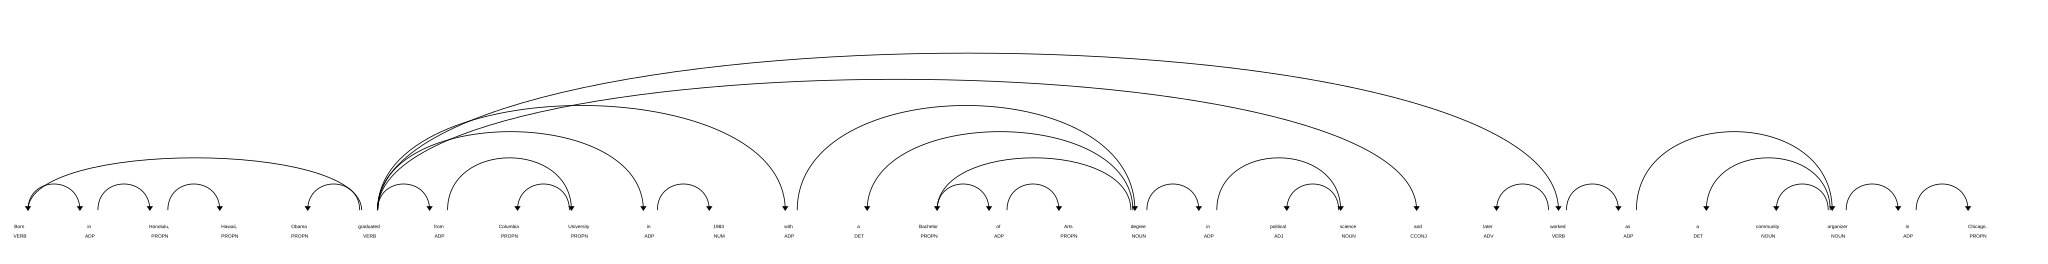

In [31]:
# Cell 6 — process the sentence with medium model
doc_md = nlp_md(sel_sentence)

print("=== Medium model: tokenization & lemmas ===")
df_md_tokens = tokens_table(doc_md)
display(df_md_tokens)

print("\n=== Medium model: POS tags (list) ===")
print([(t.text, t.pos_, t.tag_) for t in doc_md])

print("\n=== Medium model: Named Entities ===")
df_md_ents = ents_table(doc_md)
display(df_md_ents)

# Save and display dependency svg
svg_dep_md = displacy.render(doc_md, style="dep", jupyter=False)
dep_md_path = "/content/dep_md.svg"
with open(dep_md_path, "w", encoding="utf-8") as f:
    f.write(svg_dep_md)
display(SVG(dep_md_path))

# Save and display ent svg
svg_ent_md = displacy.render(doc_md, style="ent", jupyter=False)
ent_md_path = "/content/ent_md.svg"
with open(ent_md_path, "w", encoding="utf-8") as f:
    f.write(svg_ent_md)
display(SVG(ent_md_path))

=== Large model: tokenization & lemmas ===


,Token,Lemma,POS (coarse),POS (fine/tag),Dep,Head,Is_alpha,Is_stop
0,Born,bear,VERB,VBN,advcl,graduated,True,False
1,in,in,ADP,IN,prep,Born,True,True
2,Honolulu,Honolulu,PROPN,NNP,pobj,in,True,False
3,",",",",PUNCT,",",punct,Honolulu,False,False
4,Hawaii,Hawaii,PROPN,NNP,appos,Honolulu,True,False
5,",",",",PUNCT,",",punct,graduated,False,False
6,Obama,Obama,PROPN,NNP,nsubj,graduated,True,False
7,graduated,graduate,VERB,VBD,ROOT,graduated,True,False
8,from,from,ADP,IN,prep,graduated,True,True
9,Columbia,Columbia,PROPN,NNP,compound,University,True,False



=== Large model: POS tags (list) ===
[('Born', 'VERB', 'VBN'), ('in', 'ADP', 'IN'), ('Honolulu', 'PROPN', 'NNP'), (',', 'PUNCT', ','), ('Hawaii', 'PROPN', 'NNP'), (',', 'PUNCT', ','), ('Obama', 'PROPN', 'NNP'), ('graduated', 'VERB', 'VBD'), ('from', 'ADP', 'IN'), ('Columbia', 'PROPN', 'NNP'), ('University', 'PROPN', 'NNP'), ('in', 'ADP', 'IN'), ('1983', 'NUM', 'CD'), ('with', 'ADP', 'IN'), ('a', 'DET', 'DT'), ('Bachelor', 'PROPN', 'NNP'), ('of', 'ADP', 'IN'), ('Arts', 'PROPN', 'NNP'), ('degree', 'NOUN', 'NN'), ('in', 'ADP', 'IN'), ('political', 'ADJ', 'JJ'), ('science', 'NOUN', 'NN'), ('and', 'CCONJ', 'CC'), ('later', 'ADV', 'RB'), ('worked', 'VERB', 'VBD'), ('as', 'ADP', 'IN'), ('a', 'DET', 'DT'), ('community', 'NOUN', 'NN'), ('organizer', 'NOUN', 'NN'), ('in', 'ADP', 'IN'), ('Chicago', 'PROPN', 'NNP'), ('.', 'PUNCT', '.')]

=== Large model: Named Entities ===


,Text,Start_char,End_char,Label
0,Honolulu,8,16,GPE
1,Hawaii,18,24,GPE
2,Obama,26,31,PERSON
3,Columbia University,47,66,ORG
4,1983,70,74,DATE
5,a Bachelor of Arts,80,98,ORG
6,Chicago,172,179,GPE


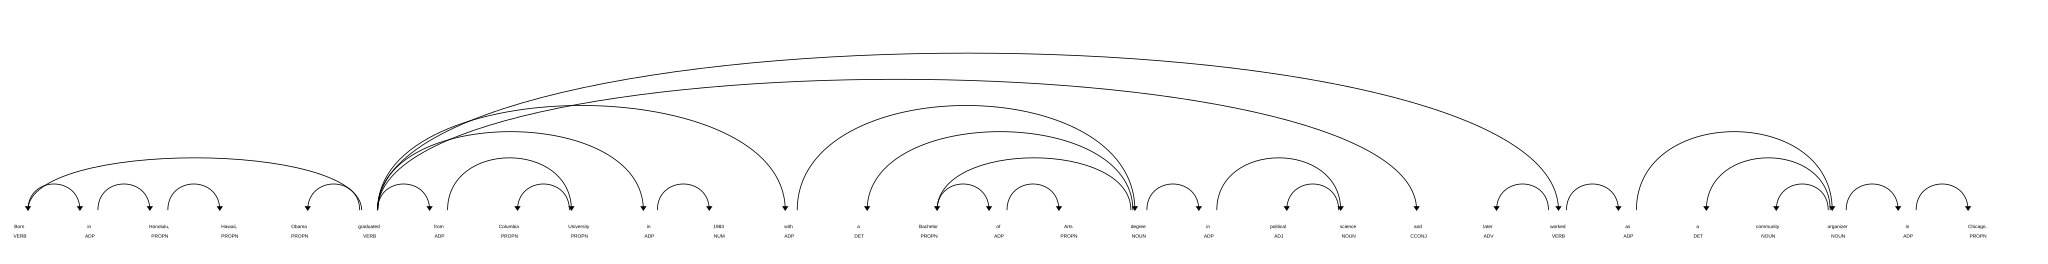

In [32]:
# Cell 7 — process the sentence with large model
doc_lg = nlp_lg(sel_sentence)

print("=== Large model: tokenization & lemmas ===")
df_lg_tokens = tokens_table(doc_lg)
display(df_lg_tokens)

print("\n=== Large model: POS tags (list) ===")
print([(t.text, t.pos_, t.tag_) for t in doc_lg])

print("\n=== Large model: Named Entities ===")
df_lg_ents = ents_table(doc_lg)
display(df_lg_ents)

# Save and display dependency svg
svg_dep_lg = displacy.render(doc_lg, style="dep", jupyter=False)
dep_lg_path = "/content/dep_lg.svg"
with open(dep_lg_path, "w", encoding="utf-8") as f:
    f.write(svg_dep_lg)
display(SVG(dep_lg_path))

# Save and display ent svg
svg_ent_lg = displacy.render(doc_lg, style="ent", jupyter=False)
ent_lg_path = "/content/ent_lg.svg"
with open(ent_lg_path, "w", encoding="utf-8") as f:
    f.write(svg_ent_lg)
display(SVG(ent_lg_path))

In [33]:
# Cell 8 — side-by-side comparison: tokens, lemmas, POS, and entities
# Merge token-level info for easier side-by-side comparison (we align by token text; note tokenization may differ)
comp_rows = []
# use indices max length
max_len = max(len(df_md_tokens), len(df_lg_tokens))
for i in range(max_len):
    md_row = df_md_tokens.iloc[i].to_dict() if i < len(df_md_tokens) else {k: None for k in df_md_tokens.columns}
    lg_row = df_lg_tokens.iloc[i].to_dict() if i < len(df_lg_tokens) else {k: None for k in df_lg_tokens.columns}
    comp_rows.append({
        "md_token": md_row.get("Token"),
        "md_lemma": md_row.get("Lemma"),
        "md_POS": md_row.get("POS (coarse)"),
        "lg_token": lg_row.get("Token"),
        "lg_lemma": lg_row.get("Lemma"),
        "lg_POS": lg_row.get("POS (coarse)"),
    })
df_comp = pd.DataFrame(comp_rows)
print("=== Token-level comparison (medium vs large) ===")
display(df_comp)

print("\n=== Entities: medium ===")
display(df_md_ents)
print("\n=== Entities: large ===")
display(df_lg_ents)

=== Token-level comparison (medium vs large) ===


,md_token,md_lemma,md_POS,lg_token,lg_lemma,lg_POS
0,Born,bear,VERB,Born,bear,VERB
1,in,in,ADP,in,in,ADP
2,Honolulu,Honolulu,PROPN,Honolulu,Honolulu,PROPN
3,",",",",PUNCT,",",",",PUNCT
4,Hawaii,Hawaii,PROPN,Hawaii,Hawaii,PROPN
5,",",",",PUNCT,",",",",PUNCT
6,Obama,Obama,PROPN,Obama,Obama,PROPN
7,graduated,graduate,VERB,graduated,graduate,VERB
8,from,from,ADP,from,from,ADP
9,Columbia,Columbia,PROPN,Columbia,Columbia,PROPN



=== Entities: medium ===


,Text,Start_char,End_char,Label
0,Honolulu,8,16,GPE
1,Hawaii,18,24,GPE
2,Obama,26,31,PERSON
3,Columbia University,47,66,ORG
4,1983,70,74,DATE
5,Chicago,172,179,GPE



=== Entities: large ===


,Text,Start_char,End_char,Label
0,Honolulu,8,16,GPE
1,Hawaii,18,24,GPE
2,Obama,26,31,PERSON
3,Columbia University,47,66,ORG
4,1983,70,74,DATE
5,a Bachelor of Arts,80,98,ORG
6,Chicago,172,179,GPE


In [34]:
# Cell 9 — automatic differences summary (simple heuristics)
differences = []

# tokenization differences (token text sequence)
md_tokens = [t.text for t in doc_md]
lg_tokens = [t.text for t in doc_lg]
if md_tokens != lg_tokens:
    differences.append("Tokenization differs between medium and large models.")

# lemma differences
lemma_diffs = [(md.text, md.lemma_, lg.lemma_) for md, lg in zip(doc_md, doc_lg) if md.lemma_ != lg.lemma_]
if lemma_diffs:
    differences.append(f"Lemma differences found for {len(lemma_diffs)} token(s). Example(s): {lemma_diffs[:5]}")

# POS differences
pos_diffs = [(md.text, md.pos_, lg.pos_) for md, lg in zip(doc_md, doc_lg) if md.pos_ != lg.pos_]
if pos_diffs:
    differences.append(f"POS tag differences for {len(pos_diffs)} token(s). Example(s): {pos_diffs[:5]}")

# NER differences
ents_md = [(ent.text, ent.label_) for ent in doc_md.ents]
ents_lg = [(ent.text, ent.label_) for ent in doc_lg.ents]
if ents_md != ents_lg:
    differences.append(f"NER differs. medium ents: {ents_md}, large ents: {ents_lg}")

print("=== Quick differences summary ===")
if differences:
    for d in differences:
        print("- " + d)
else:
    print("No differences detected by this quick heuristic.")

=== Quick differences summary ===
- NER differs. medium ents: [('Honolulu', 'GPE'), ('Hawaii', 'GPE'), ('Obama', 'PERSON'), ('Columbia University', 'ORG'), ('1983', 'DATE'), ('Chicago', 'GPE')], large ents: [('Honolulu', 'GPE'), ('Hawaii', 'GPE'), ('Obama', 'PERSON'), ('Columbia University', 'ORG'), ('1983', 'DATE'), ('a Bachelor of Arts', 'ORG'), ('Chicago', 'GPE')]


In [13]:
# Cell 10 — write-up hints (print to notebook; copy to your report)
print("=== Suggested write-up points ===\n")
print("1) Tokenization differences: mention if punctuation or contractions were split differently.")
print("2) Lemmatization: highlight any tokens where lemmas differ (e.g., proper nouns, hyphenation).")
print("3) POS & dependency: show a couple of tokens where the coarse POS or dependency label differs; "
      "explain how that could affect downstream tasks.")
print("4) NER: note differences in entity boundaries or labels (e.g., ORG vs. NORP vs. PERSON). "
      "Large models often find more/longer entities and may have higher recall.")
print("5) Visual evidence: include the two dependency SVGs and the two entity SVGs produced above, and describe differences.")
print("6) Conclusion: summarize which model you would prefer for this task and why (speed vs. accuracy/coverage).")

=== Suggested write-up points ===

1) Tokenization differences: mention if punctuation or contractions were split differently.
2) Lemmatization: highlight any tokens where lemmas differ (e.g., proper nouns, hyphenation).
3) POS & dependency: show a couple of tokens where the coarse POS or dependency label differs; explain how that could affect downstream tasks.
4) NER: note differences in entity boundaries or labels (e.g., ORG vs. NORP vs. PERSON). Large models often find more/longer entities and may have higher recall.
5) Visual evidence: include the two dependency SVGs and the two entity SVGs produced above, and describe differences.
6) Conclusion: summarize which model you would prefer for this task and why (speed vs. accuracy/coverage).
